In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

In [87]:
# memasukan file csv ke dalam jupyter / python
dfc = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_Customers.csv')
dfc.head()

,customer_id,customer_zip_code_prefix,customer_city,customer_state
0,I74lXDOfoqsp,6020,goiania,GO
1,47TuLHF2s7X5,23020,viamao,RS
2,dQ0dqI8Qwlj8,75094,campinas,SP
3,iQCmWhNkIczb,89284,santana de parnaiba,SP
4,Dp2g6JH8tO5Z,39810,aripuana,MT


In [88]:
#mengecek null values / data kosong
dfc.isnull().sum()

customer_id                 0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [89]:
#mengecek info data 
dfc.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               38279 non-null  str  
 1   customer_zip_code_prefix  38279 non-null  int64
 2   customer_city             38279 non-null  str  
 3   customer_state            38279 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.1 MB


In [90]:
# menghapus duplikat yang ada
dfc = dfc.drop_duplicates()

In [91]:
# memasukan file csv ke dalam jupyter / python
dfi = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_OrderItems.csv')
dfi.head()

,order_id,product_id,seller_id,price,shipping_charges
0,u6rPMRAYIGig,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90
1,ohY8f4FEbX19,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28
2,I28liQek73i2,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11
3,bBG1T89mlY8W,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05
4,CYxJJSQS8Lbo,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41


In [92]:
#mengecek info data 
dfi.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          38279 non-null  str    
 1   product_id        38279 non-null  str    
 2   seller_id         38279 non-null  str    
 3   price             38279 non-null  float64
 4   shipping_charges  38279 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.8 MB


In [93]:
#mengecek null values / data kosong
dfi.isnull().sum()

order_id            0
product_id          0
seller_id           0
price               0
shipping_charges    0
dtype: int64

In [94]:
#melihat bentuk data ( jumlah baris dan kolom)
dfi.shape

(38279, 5)

In [95]:
# menghapus duplikat
dfi = dfi.drop_duplicates()

In [96]:
#melihat bentuk data ( jumlah baris dan kolom) mengecek apakah ada duplikat yang terhapus jika masih sama brarti tidak ada duplikasi dalam data aslinya
dfi.shape

(38279, 5)

In [97]:
# mengimport data csv
dfo = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_Orders.csv')
dfo.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30


In [98]:
# mengecek info data
dfo.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   order_id                  38279 non-null  str  
 1   customer_id               38279 non-null  str  
 2   order_purchase_timestamp  38279 non-null  str  
 3   order_approved_at         38272 non-null  str  
dtypes: str(4)
memory usage: 3.4 MB


In [99]:
# merubah tipe data berupa string ke bentuk date
dfo['order_purchase_timestamp'] = pd.to_datetime(dfo['order_purchase_timestamp'])
dfo['order_approved_at'] = pd.to_datetime(dfo['order_approved_at'])

In [100]:
#mengecek baris dan kolom data
dfo.shape

(38279, 4)

In [101]:
# menghapus duplikat
dfo = dfo.drop_duplicates()

In [102]:
#mengecek baris dan kolom data
dfo.shape

(38279, 4)

In [103]:
#mengecek nilai null / kosong
dfo.isnull().sum()

order_id                    0
customer_id                 0
order_purchase_timestamp    0
order_approved_at           7
dtype: int64

In [104]:
#mengecek nilai null / kosong pada kolom order_approved_at
dfo[dfo['order_approved_at'].isnull()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at
309,LkbR0ufbuMHg,CERpOcaKTlre,2017-02-18 22:49:19,NaT
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,NaT
16372,KkBBPefWFP0O,HgMnfBEMEQnf,2017-02-18 22:49:19,NaT
21613,k6dIYsZLQYyJ,cqpKAGU6XHbK,2017-02-19 01:28:47,NaT
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,NaT
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,NaT
36653,G7qRNblWfEVZ,K6AeuXkv2bb7,2017-02-18 13:29:47,NaT


In [105]:
# mengimport data
dfpay = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_Payments.csv')
dfpay.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,u6rPMRAYIGig,1,credit_card,2,155.77
1,ohY8f4FEbX19,1,credit_card,1,4.07
2,I28liQek73i2,1,wallet,1,381.59
3,bBG1T89mlY8W,1,credit_card,3,14.76
4,CYxJJSQS8Lbo,1,wallet,1,284.09


In [106]:
# mengecek info data
dfpay.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              38279 non-null  str    
 1   payment_sequential    38279 non-null  int64  
 2   payment_type          38279 non-null  str    
 3   payment_installments  38279 non-null  int64  
 4   payment_value         38279 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.3 MB


In [107]:
# mengecek null value / nilai kosong
dfpay.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [108]:
# melihat jumlah baris dan kolom
dfpay.shape

(38279, 5)

In [109]:
# menghapus duplikat
dfpay = dfpay.drop_duplicates()

In [110]:
# melihat jumlah baris dan kolom
dfpay.shape

(38279, 5)

In [111]:
# mengimport data
dfprod = pd.read_csv(r'C:\Users\belzs\Documents\DATA ANALYST\Ecommerce Order Dataset\test\df_Products.csv')
dfprod.head()

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1slxdgbgWFax,toys,50.0,16.0,5.0,11.0
1,77PgsiElQLeB,electronics,200.0,21.0,7.0,14.0
2,QVlD26X1y7NI,furniture_decor,1000.0,100.0,5.0,20.0
3,yWlFGkKYfrpa,toys,8950.0,40.0,30.0,40.0
4,h6MCbrwh5kiC,toys,2301.0,32.0,35.0,34.0


In [112]:
# mengecek info data
dfprod.info()

<class 'pandas.DataFrame'>
RangeIndex: 38279 entries, 0 to 38278
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_id             38279 non-null  str    
 1   product_category_name  38111 non-null  str    
 2   product_weight_g       38269 non-null  float64
 3   product_length_cm      38269 non-null  float64
 4   product_height_cm      38269 non-null  float64
 5   product_width_cm       38269 non-null  float64
dtypes: float64(4), str(2)
memory usage: 2.4 MB


In [113]:
# mengecek null value / nilai kosong
dfprod.isnull().sum()

product_id                 0
product_category_name    168
product_weight_g          10
product_length_cm         10
product_height_cm         10
product_width_cm          10
dtype: int64

In [114]:
# mengecek null value / nilai kosong pada kolom product_category_name	
dfprod[dfprod['product_category_name'].isnull()]

,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
253,4EJ4bFIK6Xep,NaN,400.0,50.0,5.0,11.0
270,sNtRBW3JfRjj,NaN,400.0,18.0,7.0,17.0
456,PP5cKHUvzDD5,NaN,600.0,35.0,35.0,15.0
554,mHk2Zzv4Vbuz,NaN,100.0,16.0,6.0,11.0
662,QRZUjFZDGDX0,NaN,350.0,16.0,6.0,11.0
...,...,...,...,...,...,...
37265,hkUqIWaWwWpI,NaN,3550.0,40.0,10.0,40.0
37412,FxjzyI2Yzdop,NaN,200.0,25.0,2.0,18.0
37842,PP5cKHUvzDD5,NaN,600.0,35.0,35.0,15.0
38048,CLZ9JZqycnNT,NaN,10750.0,34.0,20.0,30.0


In [115]:
# melihat jumlah baris dan kolom
dfprod.shape

(38279, 6)

In [116]:
# menghapus duplikat
dfprod = dfprod.drop_duplicates()

In [117]:
# melihat jumlah baris dan kolom
dfprod.shape

(16604, 6)

In [118]:
#menggabungkan tabel dfo dengan dfc menjadi tabel dfg 
dfg = pd.merge(dfo, dfc, how='left')
dfg

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT
...,...,...,...,...,...,...,...
38274,QKBW3XKevmfn,Dw3aCTFf4Q4G,2018-08-24 11:54:56,2018-08-24 12:05:22,26160,guarulhos,SP
38275,Tjiw9bj8HtLr,JmHJqJvpVcJs,2017-03-25 20:39:11,2017-03-25 20:50:17,39628,rio de janeiro,RJ
38276,mCPofb7A1aTq,ro5DikwWCC3j,2018-08-16 13:39:30,2018-08-17 03:31:06,89284,santana de parnaiba,SP
38277,scVuqN10zbgb,R25nE2rl77AU,2018-06-27 13:17:05,2018-06-28 08:50:58,60867,sao paulo,SP


In [119]:
#menggabungkan tabel dfpay ke dalam tabel dfg
dfg = pd.merge(dfg, dfpay, how ='left')
dfg

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1,credit_card,2,155.77
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,1,credit_card,1,4.07
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,1,wallet,1,381.59
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,1,credit_card,3,14.76
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT,1,wallet,1,284.09
...,...,...,...,...,...,...,...,...,...,...,...
38274,QKBW3XKevmfn,Dw3aCTFf4Q4G,2018-08-24 11:54:56,2018-08-24 12:05:22,26160,guarulhos,SP,1,credit_card,1,209.51
38275,Tjiw9bj8HtLr,JmHJqJvpVcJs,2017-03-25 20:39:11,2017-03-25 20:50:17,39628,rio de janeiro,RJ,1,credit_card,2,323.31
38276,mCPofb7A1aTq,ro5DikwWCC3j,2018-08-16 13:39:30,2018-08-17 03:31:06,89284,santana de parnaiba,SP,1,wallet,1,170.71
38277,scVuqN10zbgb,R25nE2rl77AU,2018-06-27 13:17:05,2018-06-28 08:50:58,60867,sao paulo,SP,1,credit_card,10,100.65


In [120]:
#menggabungkan tabel dfi dan dfprod menjadi tabel df_item
df_item = pd.merge(dfi,dfprod, how = 'left')
df_item

,order_id,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,u6rPMRAYIGig,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0
1,ohY8f4FEbX19,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0
2,I28liQek73i2,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11,furniture_decor,1000.0,100.0,5.0,20.0
3,bBG1T89mlY8W,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05,toys,8950.0,40.0,30.0,40.0
4,CYxJJSQS8Lbo,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41,toys,2301.0,32.0,35.0,34.0
...,...,...,...,...,...,...,...,...,...,...
38274,QKBW3XKevmfn,wr6barwyoaIE,XURInBuULfIO,99.25,37.66,toys,200.0,16.0,28.0,11.0
38275,Tjiw9bj8HtLr,sPZVXBD9lf3e,wR4cqCClYDyY,86.32,40.98,toys,5150.0,22.0,3.0,22.0
38276,mCPofb7A1aTq,Th6SHMsyTOMH,Gp2lLacVPwug,104.45,30.24,toys,430.0,21.0,11.0,17.0
38277,scVuqN10zbgb,PyjlDSHRGdSt,al4fWZ5NFQzG,223.87,74.75,toys,1850.0,24.0,36.0,23.0


In [121]:
#menggabungkan tabel dfg dengan df_item menjadi tabel dfall
dfall = pd.merge(dfg, df_item, how = 'left')

In [122]:
#mengecek isi data tabel dfall
dfall

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1,credit_card,2,155.77,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,1,credit_card,1,4.07,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,1,wallet,1,381.59,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11,furniture_decor,1000.0,100.0,5.0,20.0
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,1,credit_card,3,14.76,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05,toys,8950.0,40.0,30.0,40.0
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT,1,wallet,1,284.09,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41,toys,2301.0,32.0,35.0,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38274,QKBW3XKevmfn,Dw3aCTFf4Q4G,2018-08-24 11:54:56,2018-08-24 12:05:22,26160,guarulhos,SP,1,credit_card,1,209.51,wr6barwyoaIE,XURInBuULfIO,99.25,37.66,toys,200.0,16.0,28.0,11.0
38275,Tjiw9bj8HtLr,JmHJqJvpVcJs,2017-03-25 20:39:11,2017-03-25 20:50:17,39628,rio de janeiro,RJ,1,credit_card,2,323.31,sPZVXBD9lf3e,wR4cqCClYDyY,86.32,40.98,toys,5150.0,22.0,3.0,22.0
38276,mCPofb7A1aTq,ro5DikwWCC3j,2018-08-16 13:39:30,2018-08-17 03:31:06,89284,santana de parnaiba,SP,1,wallet,1,170.71,Th6SHMsyTOMH,Gp2lLacVPwug,104.45,30.24,toys,430.0,21.0,11.0,17.0
38277,scVuqN10zbgb,R25nE2rl77AU,2018-06-27 13:17:05,2018-06-28 08:50:58,60867,sao paulo,SP,1,credit_card,10,100.65,PyjlDSHRGdSt,al4fWZ5NFQzG,223.87,74.75,toys,1850.0,24.0,36.0,23.0


In [123]:
#mengecek null values / nilai kosong pada tabel dfall
dfall.isnull().sum()

order_id                      0
customer_id                   0
order_purchase_timestamp      0
order_approved_at             7
customer_zip_code_prefix      0
customer_city                 0
customer_state                0
payment_sequential            0
payment_type                  0
payment_installments          0
payment_value                 0
product_id                    0
seller_id                     0
price                         0
shipping_charges              0
product_category_name       168
product_weight_g             10
product_length_cm            10
product_height_cm            10
product_width_cm             10
dtype: int64

In [124]:
#melihat nilai kosong pada kolom order_approved_at
dfall[dfall['order_approved_at'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
309,LkbR0ufbuMHg,CERpOcaKTlre,2017-02-18 22:49:19,NaT,69906,rio de janeiro,RJ,1,wallet,1,106.56,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,telephony,250.0,18.0,3.0,28.0
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,NaT,1401,novo hamburgo,RS,1,wallet,1,152.21,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,toys,1008.0,33.0,14.0,26.0
16372,KkBBPefWFP0O,HgMnfBEMEQnf,2017-02-18 22:49:19,NaT,69906,rio de janeiro,RJ,1,wallet,1,106.56,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,telephony,250.0,18.0,3.0,28.0
21613,k6dIYsZLQYyJ,cqpKAGU6XHbK,2017-02-19 01:28:47,NaT,72311,sao paulo,SP,1,wallet,1,93.52,KsJ0qytYsZlU,2a07LobkzHUx,434.99,83.60,toys,1700.0,33.0,8.0,23.0
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,NaT,92323,santos,SP,1,wallet,1,67.08,qJJWuXhXxynp,3cqSxyYyqpx6,475.00,2.46,toys,700.0,26.0,16.0,21.0
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,NaT,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,cool_stuff,1200.0,42.0,25.0,15.0
36653,G7qRNblWfEVZ,K6AeuXkv2bb7,2017-02-18 13:29:47,NaT,72601,sao paulo,SP,1,wallet,1,172.33,3CttGRrxTrK5,u3MhLPomw5UN,111.27,75.01,toys,3100.0,28.0,28.0,50.0


In [125]:
dfrio = dfall[(dfall['customer_city'] == 'rio de janeiro') & (dfall['customer_zip_code_prefix'] == 69906)]
dfrio =  dfrio.dropna()
dfrio


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
815,ehE4rCz4Lk8C,OKPaD2qEGfRW,2018-02-26 09:14:31,2018-02-26 09:35:39,69906,rio de janeiro,RJ,1,credit_card,8,1048.57,f39dws6IRteN,5Ja2lH0N2OZt,384.09,51.06,toys,22750.0,32.0,82.0,52.0
3553,1Z1qSwV5j46t,bzuvJ4ixmane,2017-03-05 19:51:44,2017-03-05 20:03:00,69906,rio de janeiro,RJ,1,credit_card,1,201.15,plejCSAfHfj4,0LjmES9V5fHW,46.20,51.45,toys,1100.0,20.0,20.0,20.0
4895,zz4MO2k4xYMd,Y8VTk80bxzFI,2018-01-16 11:51:45,2018-01-16 12:16:48,69906,rio de janeiro,RJ,1,credit_card,1,71.70,PsiIf89ti8tB,YlP5976VHgAM,3.49,20.90,toys,125.0,16.0,7.0,14.0
9542,q6T8SD6U2Geh,I9ycChV1CYDH,2017-07-23 17:46:49,2017-07-24 17:55:06,69906,rio de janeiro,RJ,1,credit_card,8,87.80,VsCOLKz81k9Z,rFT13UJuGo0Q,23.33,14.72,perfumery,500.0,16.0,16.0,22.0
10664,1STiQ1gjuei6,8xlOgenSckLY,2018-04-25 21:36:51,2018-04-25 21:51:20,69906,rio de janeiro,RJ,1,credit_card,10,38.36,P0vKFcEQSAAE,JDP75PfVyiD7,114.90,26.05,toys,17175.0,63.0,22.0,60.0
13129,3Pt1sS47lbJC,sTcecCma7H6k,2018-05-24 15:43:12,2018-05-24 15:55:26,69906,rio de janeiro,RJ,1,credit_card,1,177.54,UgkSjxoiV9Ev,UOGIrJtSldvd,56.89,28.61,toys,2600.0,50.0,10.0,30.0
13402,qlHICpNJdeqE,UBeQKIHMvLrb,2018-04-21 11:43:39,2018-04-24 19:06:50,69906,rio de janeiro,RJ,1,wallet,1,278.38,8PjU215lKh1W,vxQT8FlJeDdN,42.89,6.87,toys,100.0,16.0,16.0,11.0
19472,5EdW8NgWgfrJ,VevhLIi6jSgr,2017-02-24 21:36:00,2017-02-24 21:45:17,69906,rio de janeiro,RJ,1,credit_card,1,288.44,VPYpKJJnFC0R,eCVvpO3y8lid,232.56,2.46,garden_tools,400.0,16.0,3.0,33.0
24557,FtWbmnQOyb6Q,mGQ6ke9UUI2F,2017-04-04 00:30:54,2017-04-04 01:05:23,69906,rio de janeiro,RJ,1,credit_card,2,282.87,F7VM3KqshbPZ,j6ZQXHPSPppN,509.99,110.61,bed_bath_table,1300.0,43.0,5.0,30.0
26626,TlEcEhzyiNaw,hz9yCxsvzg8E,2018-03-03 15:38:52,2018-03-03 15:50:25,69906,rio de janeiro,RJ,1,credit_card,1,290.74,odgrVS8Yq2fd,OdnRCxXEzI4n,33.41,23.65,toys,2950.0,20.0,20.0,20.0


In [126]:
#mencari rata rata untuk mengisi nilai null
diff = dfrio['order_approved_at'] - dfrio['order_purchase_timestamp']
avg_rio =  diff.mean().round('1s')

In [127]:
# mengisi nilai null dengan rata rata yang sudah dibuat
mask = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'rio de janeiro')
dfall.loc[mask, 'order_approved_at'] = dfall.loc[mask, 'order_purchase_timestamp'] + avg_rio
dfall[(dfall['customer_city'] == 'rio de janeiro') & (dfall['customer_zip_code_prefix']== 69906)]


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
309,LkbR0ufbuMHg,CERpOcaKTlre,2017-02-18 22:49:19,2017-02-19 07:54:08,69906,rio de janeiro,RJ,1,wallet,1,106.56,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,telephony,250.0,18.0,3.0,28.0
815,ehE4rCz4Lk8C,OKPaD2qEGfRW,2018-02-26 09:14:31,2018-02-26 09:35:39,69906,rio de janeiro,RJ,1,credit_card,8,1048.57,f39dws6IRteN,5Ja2lH0N2OZt,384.09,51.06,toys,22750.0,32.0,82.0,52.0
3553,1Z1qSwV5j46t,bzuvJ4ixmane,2017-03-05 19:51:44,2017-03-05 20:03:00,69906,rio de janeiro,RJ,1,credit_card,1,201.15,plejCSAfHfj4,0LjmES9V5fHW,46.20,51.45,toys,1100.0,20.0,20.0,20.0
4895,zz4MO2k4xYMd,Y8VTk80bxzFI,2018-01-16 11:51:45,2018-01-16 12:16:48,69906,rio de janeiro,RJ,1,credit_card,1,71.70,PsiIf89ti8tB,YlP5976VHgAM,3.49,20.90,toys,125.0,16.0,7.0,14.0
9542,q6T8SD6U2Geh,I9ycChV1CYDH,2017-07-23 17:46:49,2017-07-24 17:55:06,69906,rio de janeiro,RJ,1,credit_card,8,87.80,VsCOLKz81k9Z,rFT13UJuGo0Q,23.33,14.72,perfumery,500.0,16.0,16.0,22.0
10664,1STiQ1gjuei6,8xlOgenSckLY,2018-04-25 21:36:51,2018-04-25 21:51:20,69906,rio de janeiro,RJ,1,credit_card,10,38.36,P0vKFcEQSAAE,JDP75PfVyiD7,114.90,26.05,toys,17175.0,63.0,22.0,60.0
13129,3Pt1sS47lbJC,sTcecCma7H6k,2018-05-24 15:43:12,2018-05-24 15:55:26,69906,rio de janeiro,RJ,1,credit_card,1,177.54,UgkSjxoiV9Ev,UOGIrJtSldvd,56.89,28.61,toys,2600.0,50.0,10.0,30.0
13402,qlHICpNJdeqE,UBeQKIHMvLrb,2018-04-21 11:43:39,2018-04-24 19:06:50,69906,rio de janeiro,RJ,1,wallet,1,278.38,8PjU215lKh1W,vxQT8FlJeDdN,42.89,6.87,toys,100.0,16.0,16.0,11.0
16372,KkBBPefWFP0O,HgMnfBEMEQnf,2017-02-18 22:49:19,2017-02-19 07:54:08,69906,rio de janeiro,RJ,1,wallet,1,106.56,CY8OZ3lT9uqB,sevytuBWdSFl,2899.00,2.46,telephony,250.0,18.0,3.0,28.0
19472,5EdW8NgWgfrJ,VevhLIi6jSgr,2017-02-24 21:36:00,2017-02-24 21:45:17,69906,rio de janeiro,RJ,1,credit_card,1,288.44,VPYpKJJnFC0R,eCVvpO3y8lid,232.56,2.46,garden_tools,400.0,16.0,3.0,33.0


In [128]:
# mengecek apakah sudah terisi atau masih null
dfall[dfall['order_approved_at'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,NaT,1401,novo hamburgo,RS,1,wallet,1,152.21,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,toys,1008.0,33.0,14.0,26.0
21613,k6dIYsZLQYyJ,cqpKAGU6XHbK,2017-02-19 01:28:47,NaT,72311,sao paulo,SP,1,wallet,1,93.52,KsJ0qytYsZlU,2a07LobkzHUx,434.99,83.60,toys,1700.0,33.0,8.0,23.0
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,NaT,92323,santos,SP,1,wallet,1,67.08,qJJWuXhXxynp,3cqSxyYyqpx6,475.00,2.46,toys,700.0,26.0,16.0,21.0
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,NaT,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,cool_stuff,1200.0,42.0,25.0,15.0
36653,G7qRNblWfEVZ,K6AeuXkv2bb7,2017-02-18 13:29:47,NaT,72601,sao paulo,SP,1,wallet,1,172.33,3CttGRrxTrK5,u3MhLPomw5UN,111.27,75.01,toys,3100.0,28.0,28.0,50.0


In [129]:
s723 = dfall[(dfall['customer_zip_code_prefix']== 72311) & (dfall['customer_city']== 'sao paulo')]
s723 = s723.dropna()
s723

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
12005,Md0oaXRNhv7b,sS8vEP1xVZkE,2017-10-29 10:19:49,2017-10-29 11:26:01,72311,sao paulo,SP,1,credit_card,8,209.34,ku5M1R2c0sPR,Uhxp4jLBVzJq,42.3,101.63,toys,1700.0,30.0,5.0,30.0


In [130]:
s723_diff = (s723['order_approved_at'] - s723['order_purchase_timestamp']).mean().round('1s')
s723_diff

Timedelta('0 days 01:06:12')

In [131]:
mask72311 = (dfall['order_approved_at'].isna())&(dfall['customer_zip_code_prefix']== 72311) & (dfall['customer_city']== 'sao paulo')

dfall.loc[mask72311, 'order_approved_at'] = dfall.loc[mask72311, 'order_purchase_timestamp'] + s723_diff

dfall[(dfall['customer_zip_code_prefix']== 72311) & (dfall['customer_city']== 'sao paulo')]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
12005,Md0oaXRNhv7b,sS8vEP1xVZkE,2017-10-29 10:19:49,2017-10-29 11:26:01,72311,sao paulo,SP,1,credit_card,8,209.34,ku5M1R2c0sPR,Uhxp4jLBVzJq,42.30,101.63,toys,1700.0,30.0,5.0,30.0
21613,k6dIYsZLQYyJ,cqpKAGU6XHbK,2017-02-19 01:28:47,2017-02-19 02:34:59,72311,sao paulo,SP,1,wallet,1,93.52,KsJ0qytYsZlU,2a07LobkzHUx,434.99,83.60,toys,1700.0,33.0,8.0,23.0


In [132]:
s726 = dfall[(dfall['customer_zip_code_prefix'] >= 72600) & (dfall['customer_zip_code_prefix'] <= 72699) & (dfall['customer_city'] == 'sao paulo')]
avg_s726 = (s726['order_approved_at'] - s726['order_purchase_timestamp']).mean().round('1s')
avg_s726

Timedelta('0 days 00:16:59')

In [133]:
mask726 = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'sao paulo') & (dfall['customer_zip_code_prefix'] == 72601)
dfall.loc[mask726, 'order_approved_at'] = dfall.loc[mask726, 'order_purchase_timestamp'] + avg_s726
dfall[(dfall['customer_city'] == 'sao paulo') & (dfall['customer_zip_code_prefix'] == 72601)]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
36653,G7qRNblWfEVZ,K6AeuXkv2bb7,2017-02-18 13:29:47,2017-02-18 13:46:46,72601,sao paulo,SP,1,wallet,1,172.33,3CttGRrxTrK5,u3MhLPomw5UN,111.27,75.01,toys,3100.0,28.0,28.0,50.0


In [134]:
dfall[dfall['order_approved_at'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,NaT,1401,novo hamburgo,RS,1,wallet,1,152.21,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,toys,1008.0,33.0,14.0,26.0
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,NaT,92323,santos,SP,1,wallet,1,67.08,qJJWuXhXxynp,3cqSxyYyqpx6,475.00,2.46,toys,700.0,26.0,16.0,21.0
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,NaT,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,cool_stuff,1200.0,42.0,25.0,15.0


In [135]:
novo = dfall[(dfall['customer_city'] == 'novo hamburgo') & (dfall['customer_zip_code_prefix'] == 1401)]
novo = novo.dropna()
novo

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
35614,k1zvZHZ0e9rM,Uq6WVSK5hZg7,2017-07-03 11:04:53,2017-07-03 11:23:40,1401,novo hamburgo,RS,1,credit_card,1,665.87,pKxOnQZkDwOQ,WJRLMLfPKbsX,692.0,46.76,toys,1800.0,30.0,50.0,30.0


In [136]:
novodiff = (novo['order_approved_at'] - novo['order_purchase_timestamp']).mean()
novodiff

Timedelta('0 days 00:18:47')

In [137]:
novomask = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'novo hamburgo') & (dfall['customer_zip_code_prefix'] == 1401)

dfall.loc[novomask, 'order_approved_at'] = dfall.loc[novomask, 'order_purchase_timestamp'] + novodiff

dfall[novomask]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
4699,GHrkut9FGlOd,vjsvlONwWfJb,2017-02-18 12:45:31,2017-02-18 13:04:18,1401,novo hamburgo,RS,1,wallet,1,152.21,q5EIWgf7mpli,CtMaPBruHzFA,31.58,54.64,toys,1008.0,33.0,14.0,26.0


In [138]:
santos = dfall[(dfall['customer_city'] == 'santos') & (dfall['customer_zip_code_prefix'] == 92323)]
santos = santos.dropna()
santos

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
3113,o9r1ZzsdMxK4,i1d9uQuRXr2D,2018-05-16 17:20:12,2018-05-18 01:35:20,92323,santos,SP,1,credit_card,5,167.24,rv1aC4Ckn4CM,2RAomcA7MaVK,89.91,34.33,toys,200.0,16.0,14.0,11.0
5644,sSjFlSlFgV0I,4R8nM76z3fMu,2017-06-08 18:13:24,2017-06-09 02:45:15,92323,santos,SP,1,wallet,1,316.14,EeOZRyPzDqq8,athSh1wAIt1h,59.65,88.35,toys,12700.0,18.0,105.0,40.0
5911,YuIgXZzE1WTc,VeKxvPwu58Uh,2018-03-29 12:48:18,2018-04-03 05:28:02,92323,santos,SP,1,wallet,1,174.89,ACgb0j2K7OD8,BWczKEOZMEFy,125.46,8.99,toys,1450.0,69.0,11.0,11.0
6329,dRxAmSlO9XHQ,Y5Hcl1WUvtsd,2018-04-12 16:01:15,2018-04-12 16:10:19,92323,santos,SP,1,credit_card,1,66.88,wx37t0nRxCw3,nt1w9AssyxfU,31.46,83.54,baby,250.0,16.0,16.0,16.0
7531,oEtXDPoCr9NN,0h5pUwHC9krO,2017-08-19 18:48:58,2017-08-19 19:05:09,92323,santos,SP,1,credit_card,1,168.61,sCONCvmO1cEY,0Mzbc3aACMOQ,335.99,43.26,computers_accessories,6550.0,20.0,20.0,20.0
9742,C4UB2MkM2XHp,9pinvrzDlJGT,2017-12-12 21:06:16,2017-12-12 21:16:27,92323,santos,SP,1,credit_card,4,192.68,lJ5QXXw9k2Iq,kCGmKvmZymjH,115.98,1.15,toys,425.0,19.0,13.0,16.0
10322,PlAiuBt4VNei,FMtsvYCDIXAC,2017-12-19 11:21:25,2017-12-19 11:31:32,92323,santos,SP,1,credit_card,1,90.14,5VCnKjjDHEQS,vxQT8FlJeDdN,181.56,30.66,toys,500.0,16.0,19.0,11.0
12472,rHjh47ID9v8y,9diRHrqeLrEX,2018-05-20 14:25:03,2018-05-20 14:59:15,92323,santos,SP,1,credit_card,1,150.87,Ggd3U51peXoq,8cMMpAAFEsxE,15.89,34.33,electronics,175.0,22.0,11.0,16.0
15642,3R5NJVWH09Sq,2N7sKstNXfuc,2018-01-29 12:27:32,2018-01-29 12:52:14,92323,santos,SP,1,credit_card,2,279.13,WUuMlymLkntu,AH69qRLfrouJ,69.86,15.07,toys,9300.0,82.0,53.0,43.0
18026,fygVC2SP3Tad,k0ccohMT0wBq,2018-02-16 14:21:36,2018-02-20 07:26:51,92323,santos,SP,1,wallet,1,335.86,if9uNQrIYEKf,7mxE7OgCXrJZ,11.64,46.64,toys,4050.0,31.0,24.0,26.0


In [139]:
santosdiff = ( dfall['order_approved_at'] - dfall['order_purchase_timestamp'] ).mean().round('1s')
santosdiff

Timedelta('0 days 10:28:24')

In [140]:
santosmask = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'santos') & (dfall['customer_zip_code_prefix'] == 92323)

dfall.loc[santosmask, 'order_approved_at'] = dfall.loc[santosmask, 'order_purchase_timestamp'] + santosdiff

dfall.loc[santosmask]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
28627,mppzaRpzh5lY,RUhHrezvQ33L,2017-01-19 12:48:08,2017-01-19 23:16:32,92323,santos,SP,1,wallet,1,67.08,qJJWuXhXxynp,3cqSxyYyqpx6,475.0,2.46,toys,700.0,26.0,16.0,21.0


In [141]:
jose = dfall[(dfall['customer_city'] == 'sao jose de ribamar') & (dfall['customer_zip_code_prefix'] == 30622)]
jose = jose.dropna()
jose


,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1953,ZppQrNouoHpo,jOc7uBDQ27ce,2017-12-20 13:57:37,2017-12-21 02:11:46,30622,sao jose de ribamar,MA,1,wallet,1,13.17,ztEoP22HkfQ2,l1pYW6GBnPMr,548.35,36.51,telephony,300.0,17.0,4.0,12.0
13185,NfqIp33qDIWT,TQQpfrzoGJRJ,2017-10-14 12:45:05,2017-10-14 13:07:51,30622,sao jose de ribamar,MA,1,credit_card,4,471.03,SLANLZkCbYI1,Mhg6gqpiKkO7,42.89,49.72,toys,150.0,16.0,12.0,12.0
25702,BGtWh04Ilxay,4NVL1prkzQEI,2018-08-07 05:42:46,2018-08-07 05:50:08,30622,sao jose de ribamar,MA,1,credit_card,1,280.42,hORflbR8lXFs,QgSPgHi2XQs8,48.45,23.57,toys,125.0,19.0,5.0,11.0
26019,agi0Rs8XRQpF,VEq5x6by6PR1,2018-02-09 19:55:20,2018-02-15 03:47:49,30622,sao jose de ribamar,MA,1,wallet,1,47.29,Ffe8gTdmyO3U,4cJY064rRFhL,107.63,29.05,toys,533.0,22.0,11.0,20.0
34751,ckV5MEWzS91F,SLjf9xubU9RO,2018-07-09 16:43:45,2018-07-10 09:05:25,30622,sao jose de ribamar,MA,1,credit_card,4,204.08,VyvqSoUrvQ46,EqPcJSwcfSMn,32.90,9.39,toys,363.0,18.0,13.0,13.0


In [142]:
josediff = (jose['order_approved_at'] - jose['order_purchase_timestamp']).mean().round('1s')
josediff

Timedelta('1 days 07:23:41')

In [143]:
josemask = (dfall['order_approved_at'].isna()) & (dfall['customer_city'] == 'sao jose de ribamar') & (dfall['customer_zip_code_prefix'] == 30622)

dfall.loc[josemask, 'order_approved_at'] = dfall.loc[josemask, 'order_purchase_timestamp'] + josediff

dfall[josemask]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,2017-02-20 00:38:44,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.1,67.33,cool_stuff,1200.0,42.0,25.0,15.0


In [144]:
dfall[(dfall['customer_city'] == 'sao jose de ribamar') & (dfall['customer_zip_code_prefix'] == 30622)]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1953,ZppQrNouoHpo,jOc7uBDQ27ce,2017-12-20 13:57:37,2017-12-21 02:11:46,30622,sao jose de ribamar,MA,1,wallet,1,13.17,ztEoP22HkfQ2,l1pYW6GBnPMr,548.35,36.51,telephony,300.0,17.0,4.0,12.0
13185,NfqIp33qDIWT,TQQpfrzoGJRJ,2017-10-14 12:45:05,2017-10-14 13:07:51,30622,sao jose de ribamar,MA,1,credit_card,4,471.03,SLANLZkCbYI1,Mhg6gqpiKkO7,42.89,49.72,toys,150.0,16.0,12.0,12.0
25702,BGtWh04Ilxay,4NVL1prkzQEI,2018-08-07 05:42:46,2018-08-07 05:50:08,30622,sao jose de ribamar,MA,1,credit_card,1,280.42,hORflbR8lXFs,QgSPgHi2XQs8,48.45,23.57,toys,125.0,19.0,5.0,11.0
26019,agi0Rs8XRQpF,VEq5x6by6PR1,2018-02-09 19:55:20,2018-02-15 03:47:49,30622,sao jose de ribamar,MA,1,wallet,1,47.29,Ffe8gTdmyO3U,4cJY064rRFhL,107.63,29.05,toys,533.0,22.0,11.0,20.0
30628,GdNvRBaqlJ0Z,yQHXfBlxEyWh,2017-02-18 17:15:03,2017-02-20 00:38:44,30622,sao jose de ribamar,MA,1,wallet,1,258.08,6Ww1i7qd1Zqu,YVBAT3QqF9Qj,58.10,67.33,cool_stuff,1200.0,42.0,25.0,15.0
34751,ckV5MEWzS91F,SLjf9xubU9RO,2018-07-09 16:43:45,2018-07-10 09:05:25,30622,sao jose de ribamar,MA,1,credit_card,4,204.08,VyvqSoUrvQ46,EqPcJSwcfSMn,32.90,9.39,toys,363.0,18.0,13.0,13.0


In [145]:
# mengecek nilai null pada product_category_name
dfall[dfall['product_category_name'].isna()]

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
253,QWzeukLNfMeF,tgOqRS1ySu2E,2017-04-03 17:54:02,2017-04-03 18:05:17,68903,sao paulo,SP,1,credit_card,1,732.29,4EJ4bFIK6Xep,6Gon9nN29mqW,54.98,70.34,NaN,400.0,50.0,5.0,11.0
270,OR0wt8h1DIKb,JNwZxN5F26XN,2017-03-11 11:41:42,2017-03-11 11:41:42,11380,santana de parnaiba,SP,2,voucher,1,138.70,sNtRBW3JfRjj,R7nUkxgwW9FO,126.69,55.54,NaN,400.0,18.0,7.0,17.0
456,L3T6OJnjTlXb,FJh5L8jb0KBQ,2017-05-13 20:17:09,2017-05-13 20:25:11,52160,tupa,SP,3,voucher,1,727.98,PP5cKHUvzDD5,hthWZFIJJoJh,509.99,30.66,NaN,600.0,35.0,35.0,15.0
554,gzStAybJTkfz,tSxFcQPFuVa4,2017-02-26 05:12:17,2017-03-03 02:22:26,7861,porto alegre,RS,1,wallet,1,219.23,mHk2Zzv4Vbuz,PVq5x7teCXPP,152.72,67.42,NaN,100.0,16.0,6.0,11.0
662,DY2D9uOFaz69,2G9M8wtKVV1N,2017-05-03 07:08:50,2017-05-04 10:15:19,50920,volta redonda,RJ,1,credit_card,3,174.25,QRZUjFZDGDX0,qcDsSG0VyUS9,60.09,77.10,NaN,350.0,16.0,6.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37265,Q5H3pv07a06u,jfxswjpAZ1KS,2018-05-12 17:35:56,2018-05-13 17:33:33,95350,sao caetano do sul,SP,1,credit_card,2,4.68,hkUqIWaWwWpI,FZkwqG511JFn,37.29,41.69,NaN,3550.0,40.0,10.0,40.0
37412,tyuWGoXZt3UX,hcSnIDR8uqvV,2017-10-13 10:57:04,2017-10-13 11:14:22,78055,joao monlevade,MG,1,credit_card,2,43.40,FxjzyI2Yzdop,trp1d3QYTBmA,206.57,42.76,NaN,200.0,25.0,2.0,18.0
37842,mjc8vSF6iu1Q,vFS7rWHectoa,2017-06-06 19:26:58,2017-06-06 19:42:12,51130,santo angelo,RS,1,credit_card,4,573.56,PP5cKHUvzDD5,hthWZFIJJoJh,509.99,47.55,NaN,600.0,35.0,35.0,15.0
38048,Kd3vVMBYGFan,gkA7go5OiKIn,2017-12-05 09:21:51,2017-12-05 10:48:16,36090,araras,SP,1,credit_card,1,151.35,CLZ9JZqycnNT,SSiPMxP6t9t9,261.00,115.53,NaN,10750.0,34.0,20.0,30.0


In [146]:
# mengisi nilai null pada product_category_name dengan uncategorized
dfall['product_category_name'] = dfall['product_category_name'].fillna('uncategorized')

In [147]:
# menghapus duplikat
dfall = dfall.drop_duplicates()


In [148]:
# menghapus yang berisi nilai null
dfall = dfall.dropna()

In [149]:
# mengecek nilai null
dfall.isna().sum()

order_id                    0
customer_id                 0
order_purchase_timestamp    0
order_approved_at           0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
payment_sequential          0
payment_type                0
payment_installments        0
payment_value               0
product_id                  0
seller_id                   0
price                       0
shipping_charges            0
product_category_name       0
product_weight_g            0
product_length_cm           0
product_height_cm           0
product_width_cm            0
dtype: int64

In [150]:
dfall.head()

,order_id,customer_id,order_purchase_timestamp,order_approved_at,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_id,seller_id,price,shipping_charges,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,u6rPMRAYIGig,I74lXDOfoqsp,2017-11-18 12:29:57,2017-11-18 12:46:08,6020,goiania,GO,1,credit_card,2,155.77,1slxdgbgWFax,3jwvL6ihC45G,24.10,20.90,toys,50.0,16.0,5.0,11.0
1,ohY8f4FEbX19,47TuLHF2s7X5,2018-06-02 17:13:12,2018-06-02 20:12:23,23020,viamao,RS,1,credit_card,1,4.07,77PgsiElQLeB,GlLj704QXlDB,42.89,12.28,electronics,200.0,21.0,7.0,14.0
2,I28liQek73i2,dQ0dqI8Qwlj8,2018-01-08 11:01:30,2018-01-09 07:24:03,75094,campinas,SP,1,wallet,1,381.59,QVlD26X1y7NI,V3iKL8r9W9NR,50.21,67.11,furniture_decor,1000.0,100.0,5.0,20.0
3,bBG1T89mlY8W,iQCmWhNkIczb,2017-03-10 10:24:46,2017-03-10 10:24:46,89284,santana de parnaiba,SP,1,credit_card,3,14.76,yWlFGkKYfrpa,RNBdBKsXebna,89.10,62.05,toys,8950.0,40.0,30.0,40.0
4,CYxJJSQS8Lbo,Dp2g6JH8tO5Z,2017-12-02 10:04:07,2017-12-05 04:13:30,39810,aripuana,MT,1,wallet,1,284.09,h6MCbrwh5kiC,5Ja2lH0N2OZt,2139.99,9.41,toys,2301.0,32.0,35.0,34.0


In [151]:
#Rata rata kecepatan verifikasi order
df = dfall
datediff = df['order_approved_at'] - df['order_purchase_timestamp']
datediff.mean().round('1s')

# hasil rata rata kecepatan veifikasi order menunjukan angka 10 jam 28 menit yang menandakan ada jeda waktu yang cukup lama antara saat pelanggan membayar dan sistem menyetujui pembayaran tersebut. Jika ingin meningkatkan kualitas pelayanan maka perusahaan perlu mempercepat persetujuan pembayaran tersebut dalam hitungan menit agar tidak mengurangi kepuasan pelanggan

Timedelta('0 days 10:28:35')

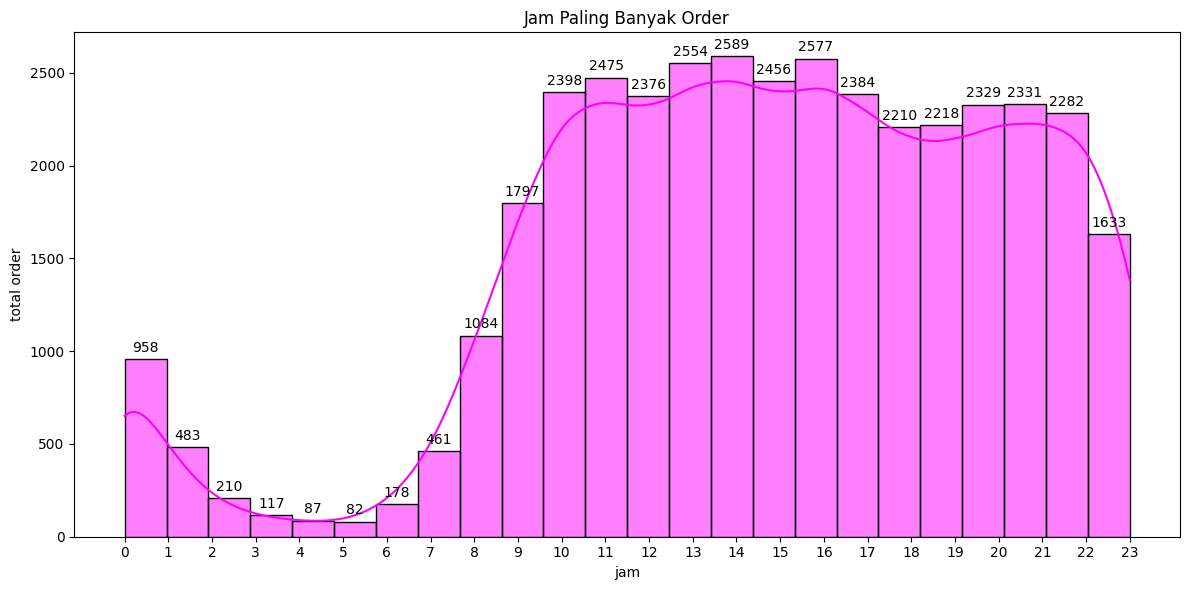

In [152]:
#jam paling banyak order

df['jam'] = df['order_purchase_timestamp'].dt.hour

plt.figure(figsize = (12,6))
ax = sns.histplot(df['jam'], bins = 24, kde = True, color = 'magenta')
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Jam Paling Banyak Order')
plt.xlabel('jam')
plt.ylabel('total order')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

#dari grafik tersebut dapat disimpulkan bahwa konsumen cenderung melakukan pembelanjaan pada sekitar jam 10 siang sampai 10 malam dan puncaknya berada pada  jam istirahat dan waktu luang pada sore hari. Perusahaan dapat menjadwalkan promosi pada jam jam tersebut untuk meningkatkan konversi

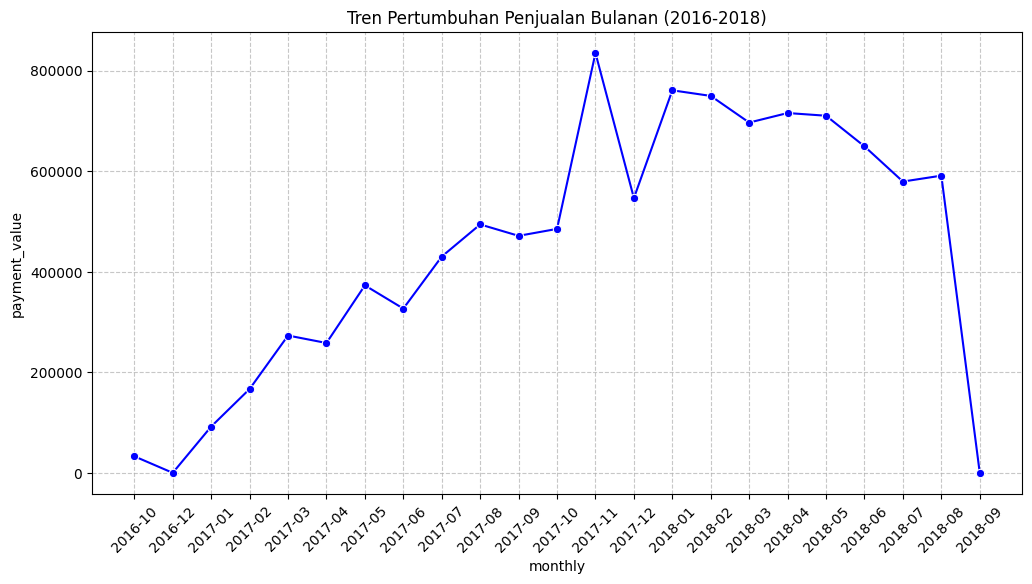

In [153]:
#trend penjualan perbulan

df['monthly'] = pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M').astype(str)

bulanan = df.groupby('monthly')['payment_value'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=bulanan, x='monthly', y='payment_value', marker='o', color='b')
plt.xticks(rotation=45)
plt.title('Tren Pertumbuhan Penjualan Bulanan (2016-2018)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Bisnis mengalami fase scaling yang sangat sehat selama satu tahun pertama. Setelah mencapai puncak di November, bisnis tampak kesulitan mempertahankan momentum pertumbuhan yang sama. Terlihat ada "cliff-fall" atau penurunan sangat tajam di bulan terakhir

In [154]:
#persentase kontribusi setiap state
state_revenue = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending= False).reset_index()
total_state_revenue = state_revenue['payment_value'].sum()
state_revenue['kontribusi'] = (state_revenue['payment_value'] / total_state_revenue) * 100  
state_revenue

# Hampir setengah dari bisnis bergantung pada satu wilayah ini. SP adalah tokoh utama pendapatan perusahaan. Pastikan infrastruktur logistik dan gudang di SP dalam kondisi prima. Biaya pengiriman ke SP harus diusahakan semurah mungkin (atau gratis) karena ini adalah basis pelanggan terbesar
# Tiga state teratas (SP, RJ, MG) jika dijumlahkan memberikan kontribusi sekitar 66,8% membuktikan bahwa ekonomi bisnis terkonsentrasi di wilayah Tenggara (Southeast) Brasil. Fokuskan kampanye iklan digital (Ads) pada koordinat geografis ini untuk mendapatkan Return on Ad Spend (ROAS) yang paling efisien

,customer_state,payment_value,kontribusi
0,SP,4246217.72,41.459372
1,RJ,1389494.31,13.566794
2,MG,1209901.17,11.813276
3,RS,589910.96,5.759794
4,PR,500394.37,4.885768
5,SC,377914.82,3.689898
6,BA,326944.31,3.192231
7,DF,236470.91,2.308863
8,GO,204953.28,2.001130
9,ES,190458.93,1.859610


In [155]:
# kontribusi city per state

city = df.groupby(['customer_city', 'customer_state'])['payment_value'].sum().sort_values(ascending= 0).reset_index()
city['total_per_state'] = city.groupby('customer_state')['payment_value'].transform('sum')
city['kontribusi'] = (city['payment_value'] / city['total_per_state'])*100
city

# Rio de Janeiro (RJ): Kota ini memiliki kontribusi sebesar 55,76% terhadap seluruh pendapatan di provinsi RJ artinya sangat terpusat di satu kota besar saja
# Sao Paulo (SP): Meskipun pendapatan kotanya paling tinggi (1,6 juta), kontribusinya terhadap provinsi SP hanya 38,17% yang menunjukkan bahwa di provinsi Sao Paulo, ekonomi lebih merata, banyak kota-kota lain yang juga menyumbang pendapatan signifikan selain ibu kotanya
# Di provinsi RJ cukup fokus beriklan di satu kota (Rio de Janeiro) untuk menguasai lebih dari separuh pasar. Namun di provinsi SP harus menyebar iklan ke banyak kota karena pasarnya lebih luas

,customer_city,customer_state,payment_value,total_per_state,kontribusi
0,sao paulo,SP,1620969.59,4246217.72,38.174434
1,rio de janeiro,RJ,774796.16,1389494.31,55.761017
2,belo horizonte,MG,300650.48,1209901.17,24.849177
3,brasilia,DF,233170.03,236470.91,98.604107
4,curitiba,PR,163674.94,500394.37,32.709189
...,...,...,...,...,...
2888,serra branca,PB,0.91,55056.32,0.001653
2889,iacri,SP,0.81,4246217.72,0.000019
2890,bernardino de campos,SP,0.80,4246217.72,0.000019
2891,pedra branca,CE,0.54,143071.45,0.000377


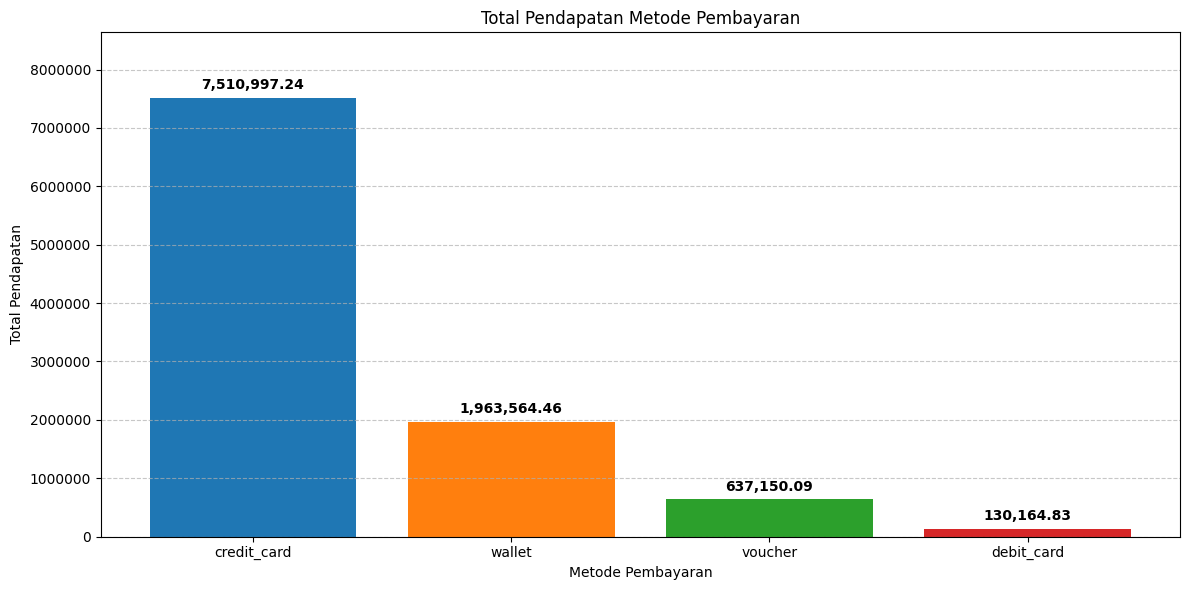

In [156]:
#Total Pendapatan per Metode Pembayaran 
tipe_pembayaran = df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=0).reset_index()
tipe_pembayaran.index = tipe_pembayaran.index + 1
tipe_pembayaran

plt.figure(figsize=(12,6))
bars = plt.bar(tipe_pembayaran['payment_type'], tipe_pembayaran['payment_value'], 
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100000, 
             f'{yval:,.2f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Total Pendapatan Metode Pembayaran')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Total Pendapatan')
plt.ticklabel_format(style='plain', axis='y')
plt.ylim(0, tipe_pembayaran['payment_value'].max() * 1.15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Kartu kredit adalah penyumbang pendapatan utama dengan angka 7,5 juta ini menunjukkan bahwa pelanggan merasa sangat nyaman melakukan transaksi besar menggunakan kartu kredit. Hal ini biasanya berkaitan dengan fitur cicilan (installments) yang sangat populer di pasar e-commerce
# Wallet memang banyak digunakan, tapi kemungkinan besar untuk transaksi dengan nilai yang lebih kecil (retail/harian), sedangkan untuk barang-barang mahal (elektronik, furnitur), pelanggan beralih ke kartu kredit
# strategi penggunaan kupon belanja (voucher) atau cashback sangat efektif. Banyaknya transaksi menggunakan voucher menandakan loyalitas pelanggan yang tinggi
# Penggunaan kartu debit kurang populer untuk belanja online. Ini menjadi masukan bagi tim produk/pembayaran bahwa mungkin tidak perlu terlalu banyak memberikan promo di metode debit, dan lebih baik fokus pada kerja sama dengan bank penyedia kartu kredit

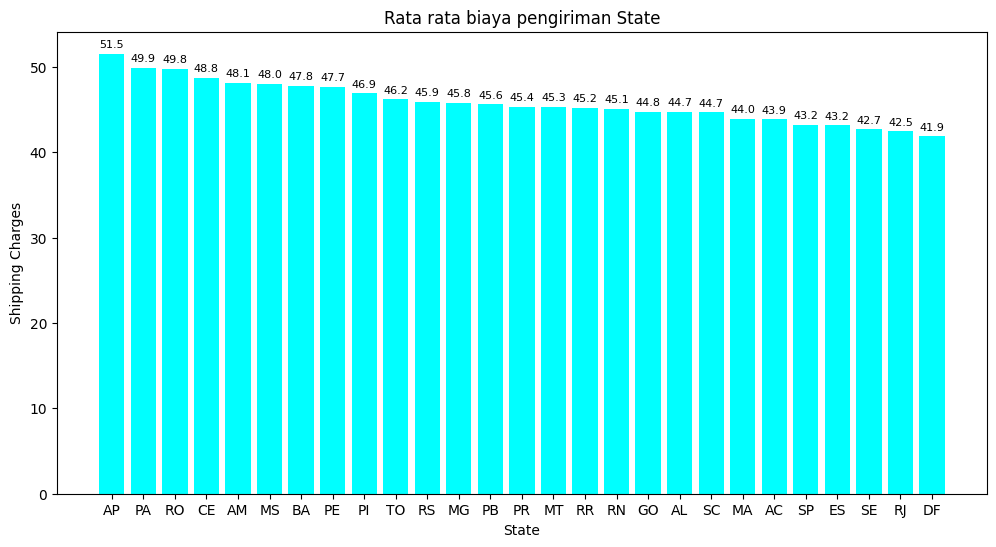

In [157]:
#state x shipping charged
shipping = df.groupby('customer_state')['shipping_charges'].mean().sort_values(ascending=0).reset_index().round(2)
shipping.index = shipping.index + 1
shipping

plt.figure(figsize=(12,6))
bars = plt.bar(shipping['customer_state'], shipping['shipping_charges'], color = 'aqua')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, 
             f'{yval:.1f}',
             ha='center', va='bottom', fontsize=8)
plt.title('Rata rata biaya pengiriman State')
plt.xlabel('State')
plt.ylabel('Shipping Charges')
plt.show()

# Meskipun ada perbedaan, rentang harganya tidak terlalu ekstrem. Ini menunjukkan bahwa penyedia logistik memiliki standar harga yang cukup kompetitif di seluruh negeri, meskipun ada tantangan infrastruktur di wilayah utara
# Ini memperkuat data sebelumnya bahwa sebagian besar pendapatan berasal dari wilayah-wilayah ini (terutama SP). Biaya pengiriman yang lebih rendah di pusat-pusat populasi ini merupakan keuntungan kompetitif untuk menarik lebih banyak pembeli di wilayah tersebut
# Jika perusahaan ingin melakukan ekspansi pasar ke wilayah utara, biaya pengiriman akan menjadi hambatan utama bagi pelanggan. Strategi seperti "Subsidi Ongkir" atau penempatan gudang (fulfillment center) di wilayah utara mungkin diperlukan untuk meningkatkan daya saing di sana

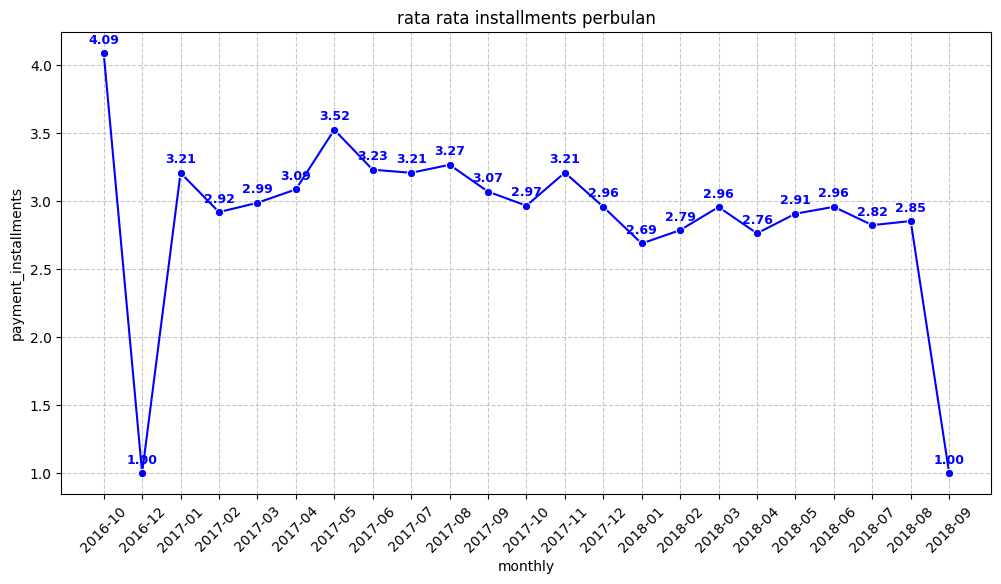

In [158]:
df_monthly_inst = df.groupby('monthly')['payment_installments'].mean().reset_index()
df_monthly_inst.index = df_monthly_inst.index + 1
df_monthly_inst

plt.figure(figsize=(12,6))
line = sns.lineplot(data=df_monthly_inst, x='monthly', y= 'payment_installments', marker= 'o', color= 'b')
for x, y in zip(df_monthly_inst['monthly'], df_monthly_inst['payment_installments']):
    plt.text(x, y + 0.05, f'{y:.2f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='blue')
plt.xticks(rotation = 45)
plt.title('rata rata installments perbulan')
plt.grid(True, linestyle = '--' , alpha = 0.7)
plt.show()

# Setelah fluktuasi di pertengahan 2017, grafik menunjukkan tren yang cukup stabil di kisaran angka 2.7 hingga 3.0 sepanjang tahun 2018. Ini menunjukkan bahwa perilaku finansial pelanggan sudah mulai terbaca. Secara rata-rata, pelanggan Anda lebih suka membagi pembayaran mereka menjadi 3 kali cicilan. Ini adalah informasi penting bagi tim marketing untuk membuat promo dengan skema Cicilan 3x Bunga 0%
# Ada tren penurunan dari bulan November 2017 (3.21) menuju Januari 2018 (2.69). Penurunan rata-rata cicilan di bulan Januari bisa mengindikasikan bahwa pelanggan mulai lebih berhati-hati dalam berutang di awal tahun, atau mereka membeli barang-barang dengan nilai yang lebih kecil yang tidak memerlukan cicilan panjang

In [159]:
#top product
top_product = df.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=0).reset_index()
top_product.index = top_product.index + 1
top_product.head(10)

,product_category_name,payment_value
1,toys,7660871.28
2,bed_bath_table,260316.45
3,health_beauty,240843.93
4,sports_leisure,216139.40
5,furniture_decor,211182.15
6,computers_accessories,196711.60
7,housewares,169736.99
8,watches_gifts,151762.51
9,garden_tools,106111.46
10,cool_stuff,102302.96


In [160]:
#K-Means to Identify Payment Installment Patterns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['payment_installments','price']].copy()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters= 3, random_state= 42 , n_init= 10)
df['cluster_cicilan'] = kmeans.fit_predict(x_scaled)

summary = df.groupby('cluster_cicilan')[['payment_installments', 'price']].mean().reset_index()
summary.index = summary.index + 1
summary

# cluster_cicilan 0 membeli barang murah (239) dan memilih cicilan sangat singkat (1,6). Mereka kemungkinan besar menggunakan kartu debit atau bayar penuh
# cluster_cicilan 1 membeli barang dengan harga serupa (236), tapi mencicil sangat panjang (7,6). Mereka sangat mengandalkan fleksibilitas pembayaran
# cluster_cicilan 2 membeli barang mahal (2.499), namun cicilannya rendah (2,6). Ini adalah pelanggan high-value yang punya likuiditas tinggi.

# Optimalisasi Penjualan Cluster 1: Karena kelompok ini sangat suka mencicil panjang untuk barang murah, Anda bisa memberikan promo cicilan 0% atau bunga rendah untuk menarik lebih banyak massa di kategori harga ini
# Eksklusivitas untuk Cluster 2: Pelanggan di Cluster 2 membeli barang mahal tapi tidak terlalu butuh banyak cicilan. Strategi yang cocok untuk mereka adalah Loyalty Program, Priority Shipping, atau akses awal ke produk high-end baru
# Up-selling untuk Cluster 0: Pelanggan ini punya pola bayar cepat. Anda bisa menawarkan produk pendamping (cross-sell) agar keranjang belanja mereka meningkat dari $239 ke angka yang lebih tinggi.

,cluster_cicilan,payment_installments,price
1,0,1.654093,239.364444
2,1,7.633593,236.579706
3,2,2.665334,2499.769543


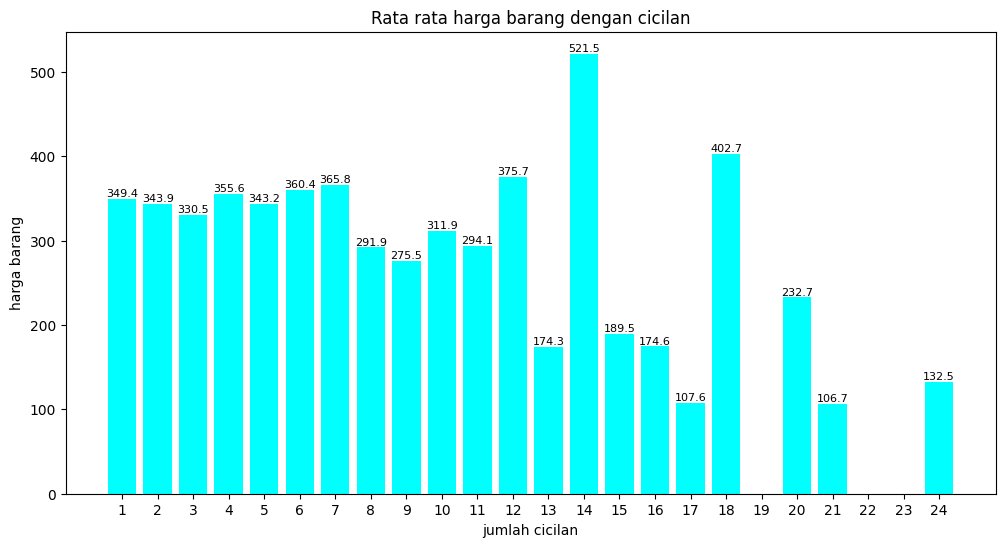

In [ ]:
barang = df.groupby('payment_installments')['price'].mean().sort_values(ascending=0).reset_index().round(2)
barang.index = barang.index + 1
barang

plt.figure(figsize=(12,6))
bars = plt.bar(barang['payment_installments'], barang['price'], color = 'aqua' )
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, 
             f'{yval:.1f}',
             ha='center', va='bottom', fontsize=8)
plt.title('Rata rata harga barang dengan cicilan')
plt.xlabel('jumlah cicilan')
plt.ylabel('harga barang')
plt.xticks(np.arange(1, 25, 1))
plt.show()

# Barang dengan rata-rata harga tertinggi dicicil sebanyak 14 dan 20 kali. Hal ini menunjukkan bahwa untuk barang yang sangat mahal, pelanggan membutuhkan tenor cicilan yang sangat panjang. tawarkan promo cicilan 0% hingga 20 bulan. Fokuskan iklan produk ini pada keuntungan cicilan ringan per bulan untuk menarik minat pelanggan
# Untuk barang dengan harga rata-rata 330–360, pelanggan cukup konsisten menggunakan cicilan jangka pendek. Ini adalah segmen pasar paling aman dan paling banyak transaksinya. Dorong peningkatan volume dengan promo cicilan 3-6 bulan tanpa DP karena ini adalah area di mana perputaran uang paling cepat.

In [ ]:
correlation = df['price'].corr(df['payment_installments'])
correlation

-0.02084547164420897

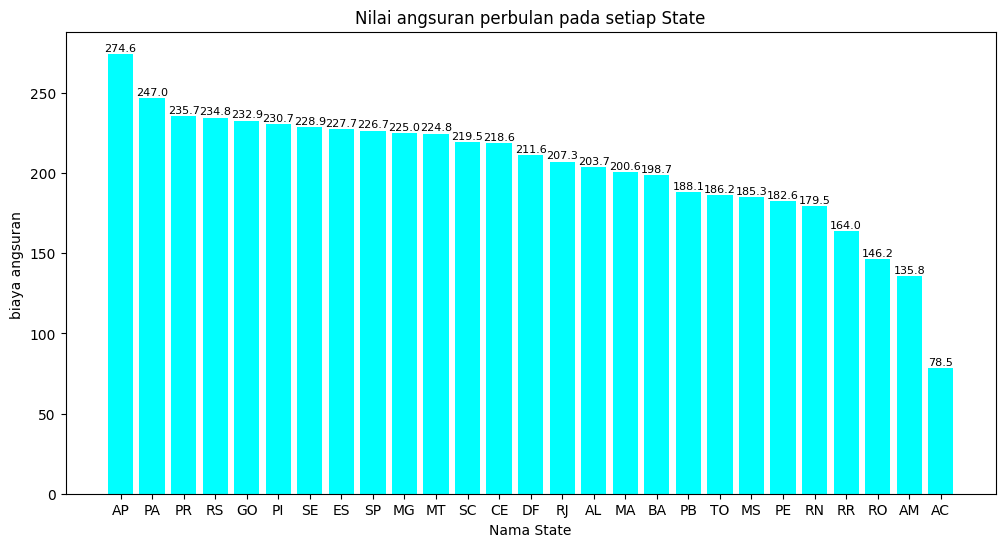

In [ ]:
df['monthly_installment_value'] = df['price'] / df['payment_installments']
angsuran_bulan = df.groupby('customer_state')['monthly_installment_value'].mean().sort_values(ascending=0).reset_index()
angsuran_bulan

plt.figure(figsize=(12,6))
bars = plt.bar(angsuran_bulan['customer_state'], angsuran_bulan['monthly_installment_value'], color = 'aqua')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, 
             f'{yval:.1f}',
             ha='center', va='bottom', fontsize=8)
plt.title('Nilai angsuran perbulan pada setiap State')
plt.xlabel('Nama State')
plt.ylabel('biaya angsuran ')
plt.show()

# State bagian seperti AP  dan PA tidak hanya memiliki biaya pengiriman tertinggi , tetapi juga memiliki nilai angsuran bulanan tertinggi. Pelanggan di wilayah ini menanggung beban finansial ganda yaitu ongkir yang mahal dan nilai cicilan bulanan yang tinggi. Hal ini menunjukkan bahwa pelanggan di wilayah terpencil tetap melakukan pembelian barang bernilai tinggi meskipun ada hambatan logistik. Berikan subsidi biaya pengiriman khusus wilayah tersebut untuk menjaga loyalitas.
# State seperti SP dan RJ berada di area tengah-bawah grafik karena biaya pengiriman di wilayah ini lebih murah, pelanggan mungkin memiliki fleksibilitas lebih dalam memilih tenor cicilan atau membeli barang dengan total harga yang lebih kompetitif, sehingga nilai angsuran bulanannya lebih stabil dan tidak seberat wilayah AP dan PA. Fokuskan iklan produk untuk meningkatkan daya beli pada daerah ini dikarenakan biaya pengiriman murah dan tebir cicilan stabil

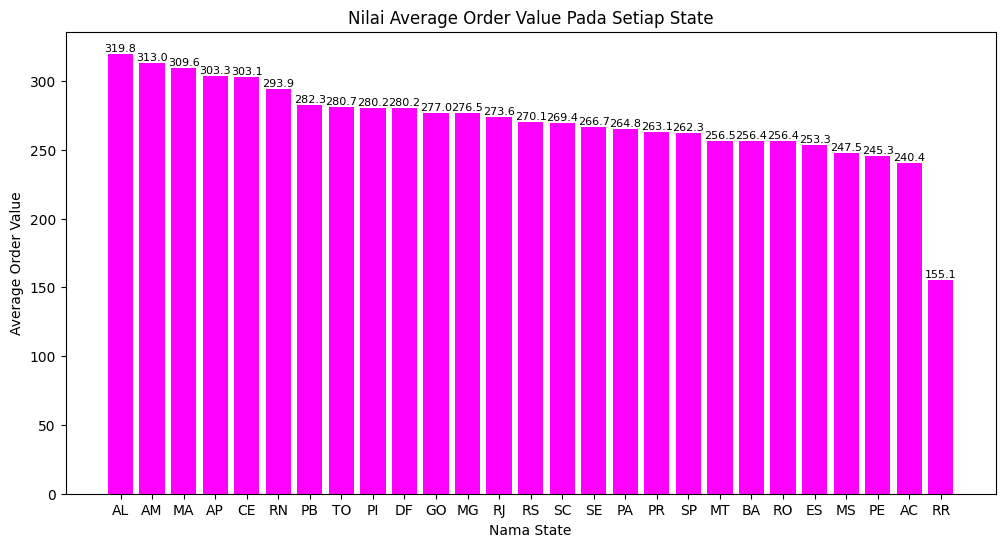

In [ ]:
#aov 
order_total = df.groupby(['order_id', 'customer_state'])['payment_value'].sum().reset_index()
aov = order_total.groupby('customer_state')['payment_value'].mean().sort_values(ascending= 0).reset_index()
aov.index = aov.index +1
aov

plt.figure(figsize=(12,6))
bars = plt.bar(aov['customer_state'], aov['payment_value'], color = 'magenta')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+ bar.get_width()/2, yval + 0.5, 
             f'{yval:.1f}',
             ha='center', va='bottom', fontsize=8)
plt.title('Nilai Average Order Value Pada Setiap State')
plt.xlabel('Nama State')
plt.ylabel('Average Order Value')
plt.show()

# State seperti AL, AM, MA, dan AP berada di puncak karena memiliki biaya kirim termahal, pelanggan dipaksa belanja dalam nilai besar sekaligus agar biaya kirimnya terasa lebih sepadan
# State seperti SP, RJ, dan MG berada di papan tengah atau bawah karena ongkir murah, mereka lebih santai untuk belanja barang murah secara eceran berkali-kali
# Garis rata-rata AOV berada di kisaran 270 - 320 maka bisa menetapkan batas Gratis Ongkir sedikit di atas rata-rata misalnya belanja minimal 350 untuk mendorong pelanggan menambah satu atau dua barang lagi ke keranjang mereka

18:55:49 - cmdstanpy - INFO - Chain [1] start processing
18:55:50 - cmdstanpy - INFO - Chain [1] done processing


Hasil Prediksi 30 Hari ke Depan:
            ds       yhat  yhat_lower  yhat_upper
637 2018-09-29  53.210462   27.365366   79.620066
638 2018-09-30  56.706152   30.909419   83.517697
639 2018-10-01  77.397285   51.271903  103.877741
640 2018-10-02  77.271914   51.397239  105.344306
641 2018-10-03  76.100951   49.018443  103.467290


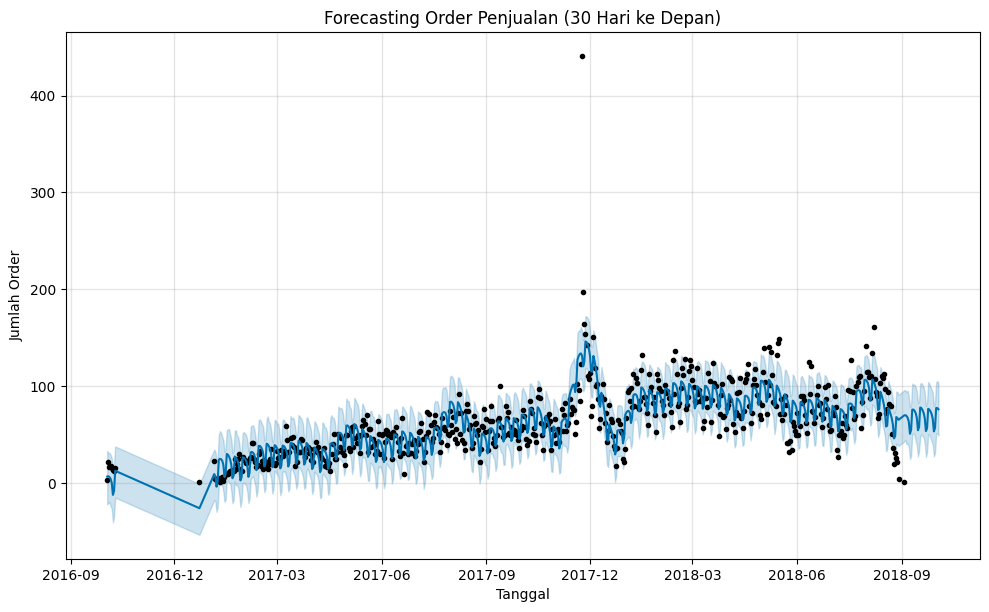

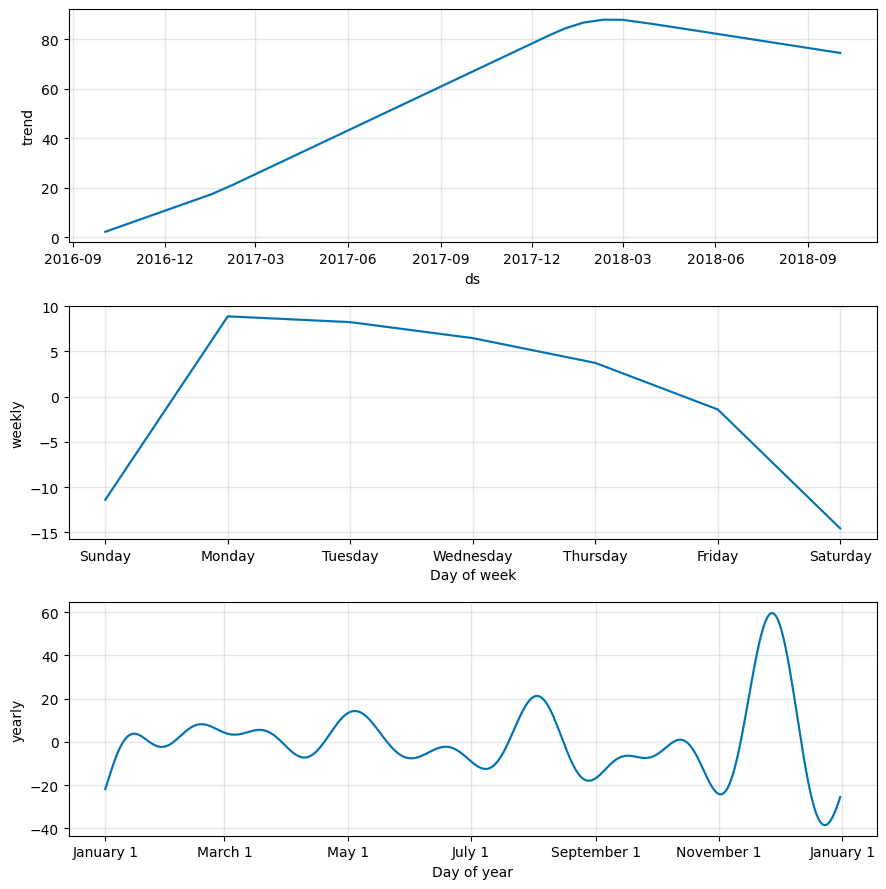

In [ ]:
#analisis time series menggunakan Prophet
df_ts = df.copy()
daily_orders = df_ts.groupby(df_ts['order_purchase_timestamp'].dt.date).size().reset_index()
daily_orders.columns = ['ds', 'y']
daily_orders['ds'] = pd.to_datetime(daily_orders['ds'])
model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=True, 
    daily_seasonality=False
)
model.fit(daily_orders)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)
print("Hasil Prediksi 30 Hari ke Depan:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

fig1 = model.plot(forecast)
plt.title('Forecasting Order Penjualan (30 Hari ke Depan)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Order')
plt.show()
fig2 = model.plot_components(forecast)
plt.show()

# Bisnis mengalami pertumbuhan yang sangat pesat sejak awal 2017 hingga mencapai puncaknya di awal 2018. Meskipun sempat ada sedikit penurunan melandai di kuartal kedua 2018, volume transaksi tetap berada di level yang jauh lebih tinggi dibanding tahun sebelumnya.
# Pesanan mulai melonjak tajam pada hari Senin dan mencapai puncaknya pada hari tersebut, kemudian menurun secara bertahap hingga titik terendah pada hari Sabtu. Ini menunjukkan perilaku belanja awal minggu yang sangat dominan. Karena trafik memuncak di hari Senin, luncurkan kampanye iklan atau notifikasi aplikasi pada hari Minggu malam atau Senin pagi untuk memaksimalkan konversi saat pelanggan paling aktif berbelanja
# Terdapat lonjakan besar yang konsisten pada bulan Mei dan November (jelang Natal). Penurunan terdalam terjadi di bulan Januari, yang merupakan periode umum penurunan konsumsi setelah libur akhir tahun. Siapkan stok gudang dan kapasitas logistik lebih besar pada bulan April dan Oktober. Gunakan data Prophet untuk memprediksi jumlah stok yang dibutuhkan agar tidak terjadi out-of-stock saat permintaan memuncak lalu Untuk mengatasi penurunan di bulan Januari, buatlah kampanye "New Year Resolution" untuk menarik minat pelanggan yang cenderung hemat setelah liburan